In [2]:
!pip install lime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, warnings, time
from scipy.stats import pearsonr

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.inspection import permutation_importance

import shap
import lime
import lime.lime_tabular
%matplotlib inline
warnings.filterwarnings('ignore')

  Using cached lime-0.2.0.1.tar.gz (275 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached imageio-2.37.3-py3-none-any.whl.metadata (9.7 kB)
  Using cached tifffile-2026.6.1-py3-none-any.whl.metadata (33 kB)
  Using cached lazy_loader-0.5-py3-none-any.whl.metadata (5.9 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 35.3 kB/s eta 0:00:0000:0100:09
Using cached imageio-2.37.3-py3-none-any.whl (317 kB)
Using cached lazy_loader-0.5-py3-none-any.whl (8.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.1/267.1 kB 35.7 kB/s eta 0:00:00a 0:00:01
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283913 sha256=f78d7a1b0c294d4fc2f1f928522936a3a1073f8b04ebbe026f8559541a73a352
  Stored in directory: /home/wjj/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [3]:
BASE_DIR = "../"
DATA_PATH = os.path.join(BASE_DIR, "data", "cancer_data_eng.csv")
IMG_DIR = os.path.join(BASE_DIR, "img")
RESULTS_DIR = os.path.join(BASE_DIR, "results")

os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
RANDOM_STATE = 42
N_SAMPLES = 10000

In [4]:
print("\n[0] 加载数据...")
df = pd.read_csv(DATA_PATH, low_memory=False, encoding='latin-1')
df['target'] = df['Status.Vital'].map({'VIVO': 1, 'MORTO': 0})
df = df.dropna(subset=['target'])
np.random.seed(RANDOM_STATE)
if len(df) > N_SAMPLES:
    idx = np.random.choice(len(df), N_SAMPLES, replace=False)
    df = df.iloc[idx].copy()

# 特征选择 (用此前特征工程/特征选择的结果)
feature_cols = ['Age', 'year', 'Code.Profession', 'Diagnostic.means',
                'Extension', 'Raca.Color']
df_feat = df[feature_cols + ['target']].copy()

cat_cols = ['Diagnostic.means', 'Extension', 'Raca.Color']
for col in cat_cols:
    le = LabelEncoder()
    non_null = df_feat[col].dropna().astype(str)
    le.fit(non_null)
    mc = non_null.value_counts().index[0]
    def encode(x, le=le, mc=mc):
        if pd.isna(x): return np.nan
        xs = str(x)
        return le.transform([xs])[0] if xs in le.classes_ else le.transform([mc])[0]
    df_feat[col] = df_feat[col].apply(encode)

X = df_feat[feature_cols].astype(float).values
y = df_feat['target'].values
feature_names_short = np.array(feature_cols)

n_pos = (y == 1).sum()
n_neg = (y == 0).sum()
print(f"    总样本: {len(X):,}  VIVO: {n_pos:,} ({n_pos/len(X)*100:.2f}%)")

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)
print(f"    训练集: {len(X_tr):,}  测试集: {len(X_te):,}")

# 预处理
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()
X_tr_imp = imputer.fit_transform(X_tr)
X_te_imp = imputer.transform(X_te)
X_tr_final = scaler.fit_transform(X_tr_imp)
X_te_final = scaler.transform(X_te_imp)



[0] 加载数据...
    总样本: 10,000  VIVO: 4,123 (41.23%)
    训练集: 7,000  测试集: 3,000


In [5]:

# ============================================================================
# 训练主模型 — Random Forest (AUC最高+稳定性最好)
# ============================================================================
print("\n[1] 训练主模型 (Random Forest)...")
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=8, class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1)
rf_model.fit(X_tr_final, y_tr)
y_prob = rf_model.predict_proba(X_te_final)[:, 1]
auc = roc_auc_score(y_te, y_prob)
print(f"    RF 测试 AUC = {auc:.4f}")


[1] 训练主模型 (Random Forest)...
    RF 测试 AUC = 0.9104



[A1] 内置 Feature Importance (Gini Importance)...
  [图] 15a_feature_importance.png 已保存


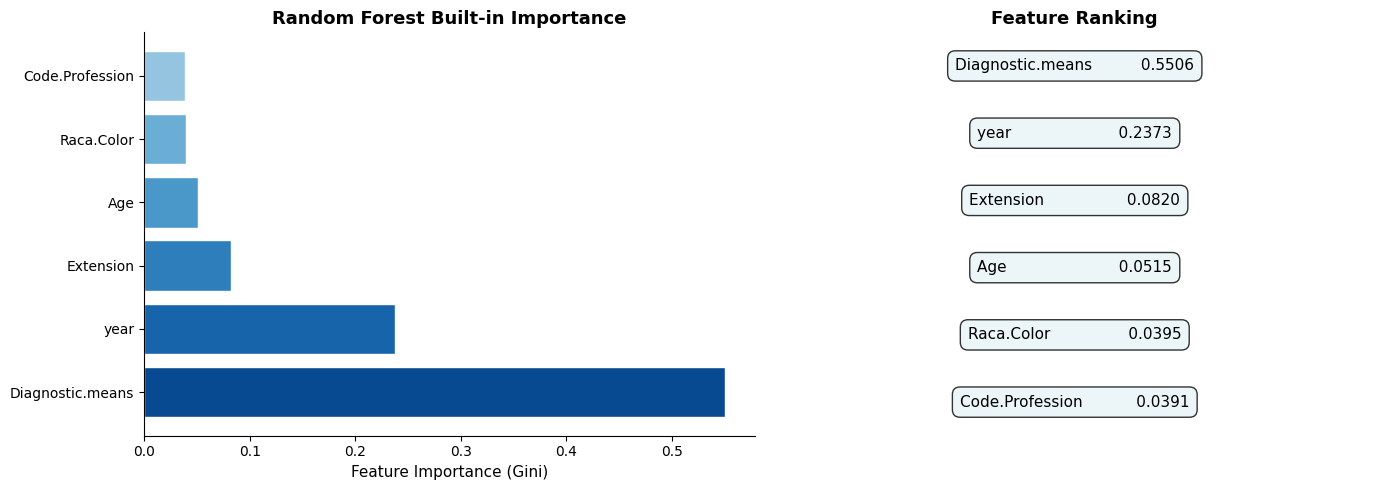

In [6]:
# --- A1: 内置 Feature Importance (Gini Importance) ---
print("\n[A1] 内置 Feature Importance (Gini Importance)...")
importances = rf_model.feature_importances_
fi_idx = np.argsort(importances)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图: 条形图
colors_fi = plt.cm.Blues(np.linspace(0.4, 0.9, len(feature_names_short)))
axes[0].barh(range(len(feature_names_short)),
              importances[fi_idx], color=colors_fi[::-1], edgecolor='white')
axes[0].set_yticks(range(len(feature_names_short)))
axes[0].set_yticklabels([feature_names_short[i] for i in fi_idx])
axes[0].set_xlabel('Feature Importance (Gini)', fontsize=11)
axes[0].set_title('Random Forest Built-in Importance', fontsize=13, fontweight='bold')
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

# 右图: 特征排序 + 重要性数值
for i in range(len(feature_names_short)):
    axes[1].text(0.5, 1 - (i+0.5)/len(feature_names_short),
                 f"{feature_names_short[fi_idx[i]]:<25} {importances[fi_idx[i]]:.4f}",
                 fontsize=11, ha='center', va='center',
                 bbox=dict(boxstyle='round,pad=0.5', facecolor='#e8f4f8', alpha=0.8))
axes[1].set_xlim([0, 1]); axes[1].set_ylim([0, 1])
axes[1].axis('off')
axes[1].set_title('Feature Ranking', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "15a_feature_importance.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 15a_feature_importance.png 已保存")



[A2] Permutation Importance...
  [图] 15b_permutation_importance.png 已保存


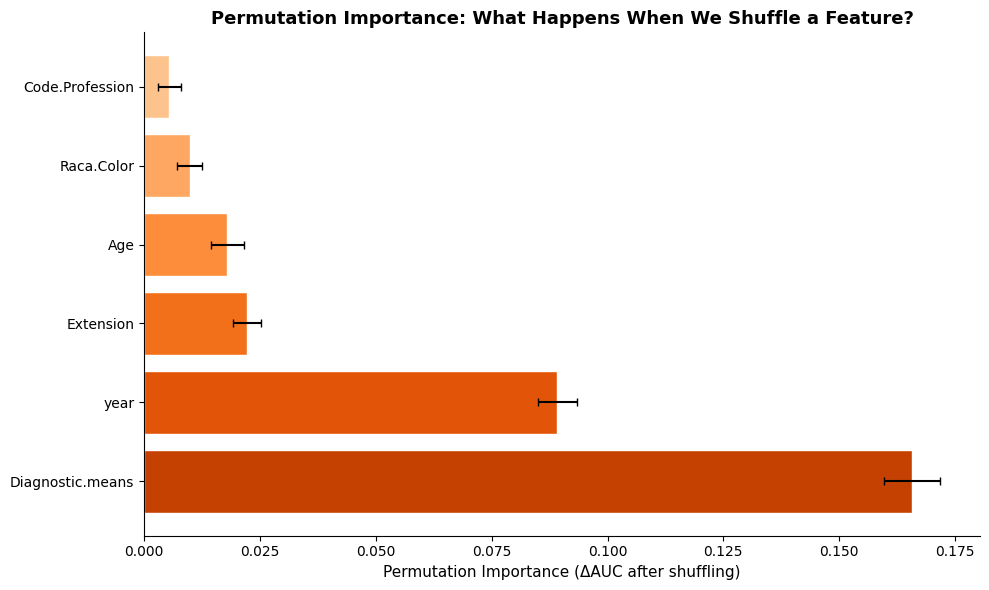

In [7]:
# --- A2: Permutation Importance ---
print("\n[A2] Permutation Importance...")
perm_result = permutation_importance(
    rf_model, X_te_final, y_te, n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
perm_imp_mean = perm_result.importances_mean
perm_imp_std = perm_result.importances_std
perm_idx = np.argsort(perm_imp_mean)[::-1]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(feature_names_short)),
         perm_imp_mean[perm_idx],
         xerr=perm_imp_std[perm_idx],
         color=plt.cm.Oranges(np.linspace(0.3, 0.8, len(feature_names_short))[::-1]),
         edgecolor='white', capsize=3)
ax.set_yticks(range(len(feature_names_short)))
ax.set_yticklabels([feature_names_short[i] for i in perm_idx])
ax.set_xlabel('Permutation Importance (ΔAUC after shuffling)', fontsize=11)
ax.set_title('Permutation Importance: What Happens When We Shuffle a Feature?',
             fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "15b_permutation_importance.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 15b_permutation_importance.png 已保存")

In [8]:
print(f"\n  {'Feature':<25} {'Gini Importance':>16} {'Perm Importance':>16} {'Perm σ':>10}")
print(f"  {'-'*25} {'-'*16} {'-'*16} {'-'*10}")
for i in range(len(feature_names_short)):
    fn = feature_names_short[i]
    fi = importances[i]
    pi = perm_imp_mean[i]
    ps = perm_imp_std[i]
    print(f"  {fn:<25} {fi:>16.4f} {pi:>16.4f} {ps:>10.4f}")


  Feature                    Gini Importance  Perm Importance     Perm σ
  ------------------------- ---------------- ---------------- ----------
  Age                                 0.0515           0.0180     0.0036
  year                                0.2373           0.0892     0.0042
  Code.Profession                     0.0391           0.0055     0.0025
  Diagnostic.means                    0.5506           0.1657     0.0061
  Extension                           0.0820           0.0221     0.0030
  Raca.Color                          0.0395           0.0098     0.0027


In [9]:
print("\n[A3] SHAP 全局分析 (TreeExplainer)...")
explainer = shap.TreeExplainer(rf_model)
# 用测试集子集（500 样本）加速
n_shap = min(500, len(X_te_final))
X_shap = X_te_final[:n_shap]
y_shap = y_te[:n_shap]
shap_values = explainer.shap_values(X_shap)

# shap_values 是三维数组 [n_samples, n_features, n_classes]
# 对于二分类，取正类的 SHAP 值
print(f"    shap_values type={type(shap_values)}")
if isinstance(shap_values, list):
    sv = shap_values[1]  # 正类 (VIVO)
    print(f"    sv shape (from list[1]): {sv.shape}")
else:
    sv = shap_values
    print(f"    sv shape (from direct): {sv.shape}")
    # 如果 sv 是3维，取正类
    if sv.ndim == 3:
        sv = sv[:, :, 1]
        print(f"    sv shape (after taking class 1): {sv.shape}")


[A3] SHAP 全局分析 (TreeExplainer)...
    shap_values type=<class 'numpy.ndarray'>
    sv shape (from direct): (500, 6, 2)
    sv shape (after taking class 1): (500, 6)


  [图] 15c_shap_summary.png (Bee Swarm) 已保存


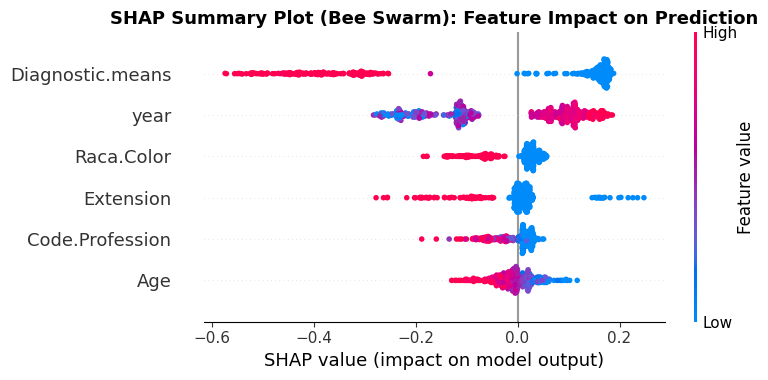

In [10]:
# --- A3-1: SHAP Summary Plot (Bee Swarm) ---
plt.figure(figsize=(12, 6))
shap.summary_plot(sv, X_shap, feature_names=feature_names_short,
                  show=False, max_display=len(feature_names_short))
plt.title('SHAP Summary Plot (Bee Swarm): Feature Impact on Prediction',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "15c_shap_summary.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 15c_shap_summary.png (Bee Swarm) 已保存")

  [图] 15d_shap_bar.png 已保存


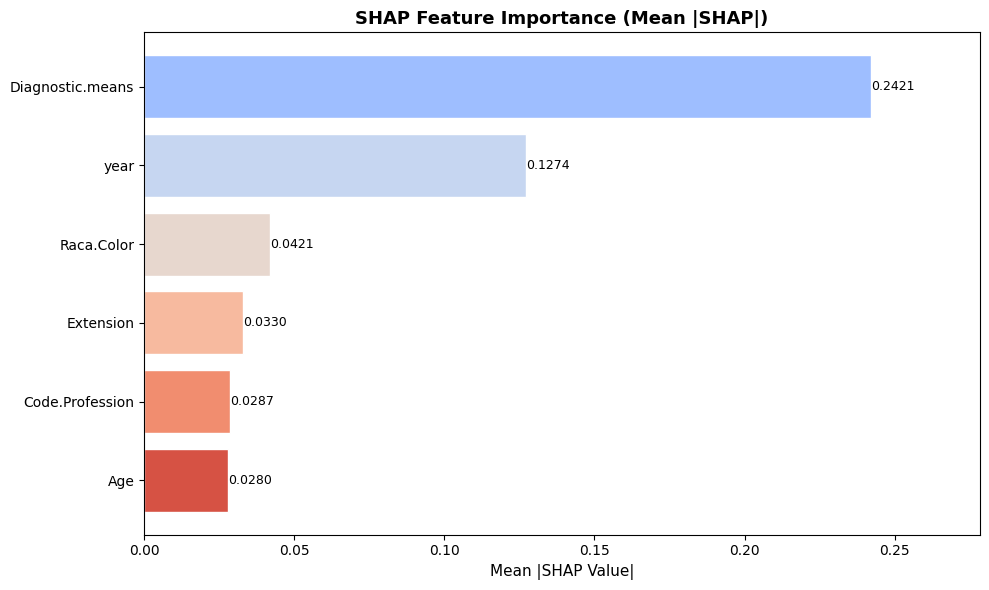

In [11]:
# --- A3-2: SHAP Bar Plot ---
plt.figure(figsize=(10, 6))
shap_importance = np.abs(sv).mean(0)
bar_idx = np.argsort(shap_importance)

colors_sbar = plt.cm.coolwarm(np.linspace(0.3, 0.9, len(feature_names_short)))
plt.barh(range(len(feature_names_short)), shap_importance[bar_idx],
         color=colors_sbar[::-1], edgecolor='white')
plt.yticks(range(len(feature_names_short)),
           [feature_names_short[i] for i in bar_idx])
plt.xlabel('Mean |SHAP Value|', fontsize=11)
plt.title('SHAP Feature Importance (Mean |SHAP|)',
          fontsize=13, fontweight='bold')
for i in range(len(feature_names_short)):
    plt.text(shap_importance[bar_idx][i], i,
             f'{shap_importance[bar_idx][i]:.4f}',
             ha='left', va='center', fontsize=9)
plt.xlim([0, shap_importance.max() * 1.15])
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "15d_shap_bar.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 15d_shap_bar.png 已保存")

  [图] 15e_shap_dependence_{1,2}.png 已保存


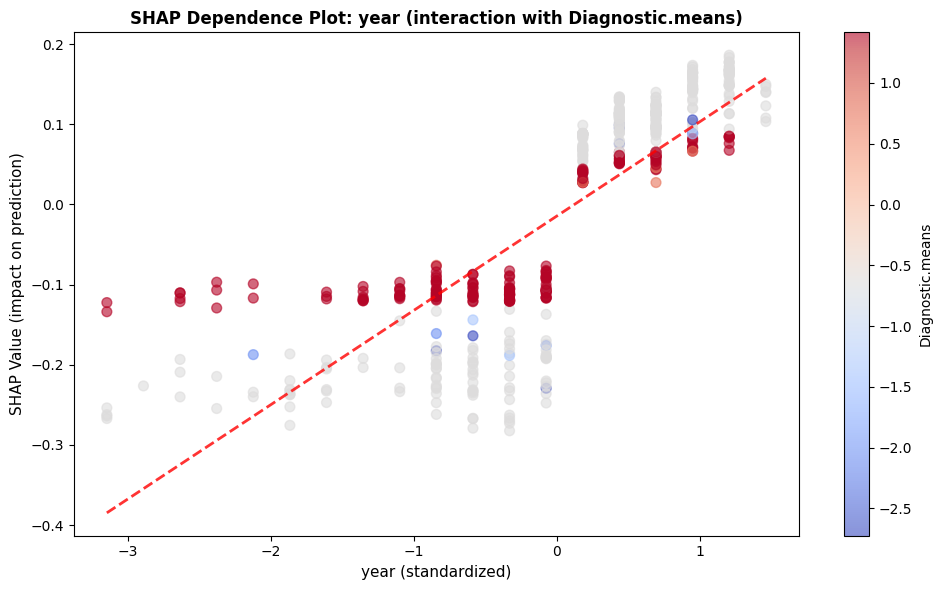

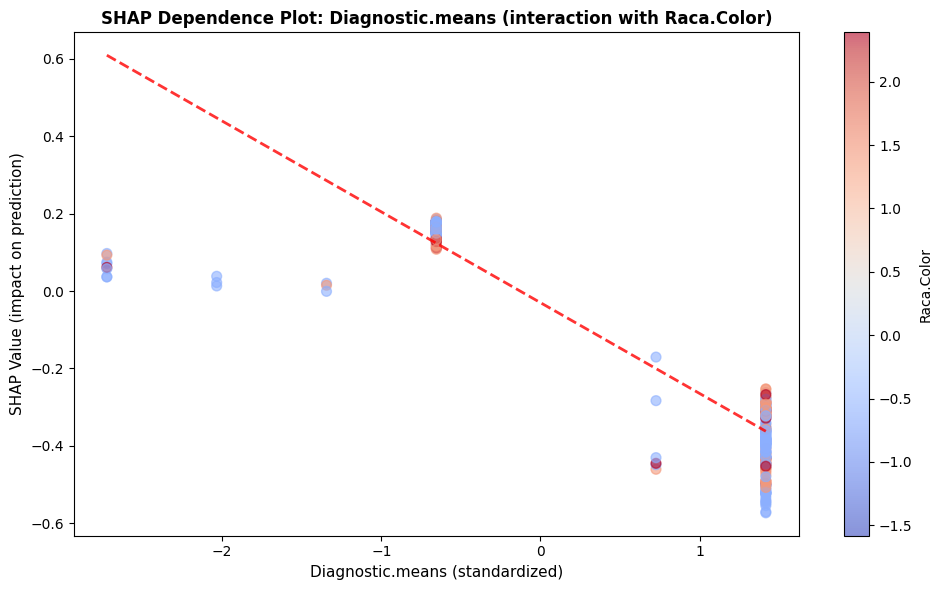

In [12]:
# --- A3-3: SHAP Dependence Plots (Top 2 features) ---
top2_idx = np.argsort(shap_importance)[-2:]

for rank, idx in enumerate(top2_idx):
    plt.figure(figsize=(10, 6))
    fn = feature_names_short[idx]

    # 找交互特征: 与当前特征 SHAP 值相关性最强的其他特征
    correlations = []
    for j in range(X_shap.shape[1]):
        if j != idx:
            corr, _ = pearsonr(X_shap[:, j], sv[:, idx])
            correlations.append((j, abs(corr)))
    if correlations:
        interaction_idx = max(correlations, key=lambda x: x[1])[0]
        scatter = plt.scatter(
            X_shap[:, idx], sv[:, idx],
            c=X_shap[:, interaction_idx],
            cmap='coolwarm', alpha=0.6, s=50)

        # 趋势线
        z = np.polyfit(X_shap[:, idx], sv[:, idx], 1)
        p = np.poly1d(z)
        x_sorted = np.sort(X_shap[:, idx])
        plt.plot(x_sorted, p(x_sorted), "r--", alpha=0.8, lw=2)

        plt.xlabel(f'{fn} (standardized)', fontsize=11)
        plt.ylabel('SHAP Value (impact on prediction)', fontsize=11)
        plt.title(f'SHAP Dependence Plot: {fn} (interaction with {feature_names_short[interaction_idx]})',
                  fontsize=12, fontweight='bold')
        cbar = plt.colorbar(scatter)
        cbar.set_label(f'{feature_names_short[interaction_idx]}', fontsize=10)
    else:
        plt.scatter(X_shap[:, idx], sv[:, idx], alpha=0.6, s=50)
        plt.xlabel(f'{fn}', fontsize=11)
        plt.ylabel('SHAP Value', fontsize=11)

    plt.tight_layout()
    plt.savefig(os.path.join(IMG_DIR, f"15e_shap_dependence_{rank+1}.png"),
                dpi=150, bbox_inches='tight')
    # plt.close()
print("  [图] 15e_shap_dependence_{1,2}.png 已保存")

  [图] 15f_shap_interaction.png 已保存


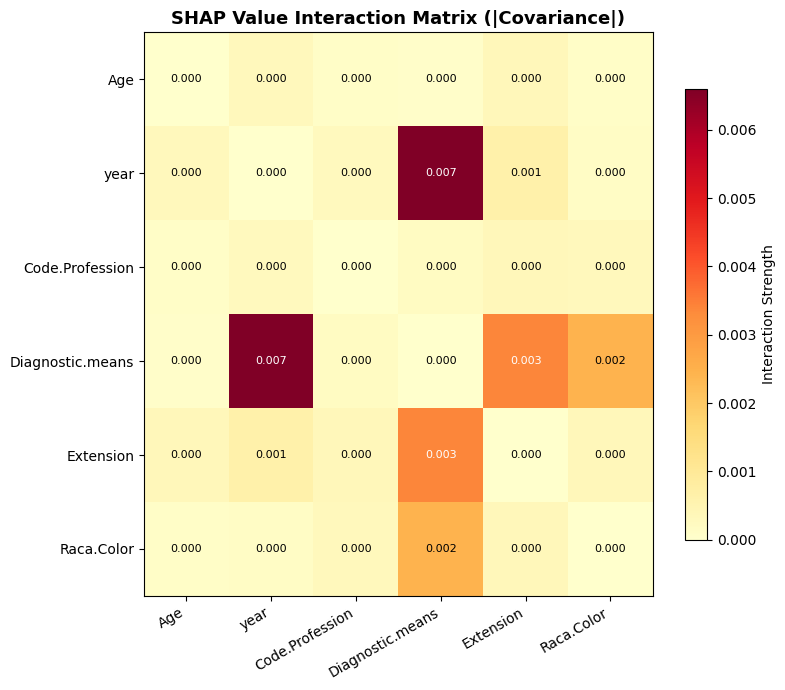

In [13]:
# --- A3-4: SHAP Interaction Heatmap ---
shap_interaction = np.zeros((len(feature_names_short), len(feature_names_short)))
for i in range(len(feature_names_short)):
    for j in range(len(feature_names_short)):
        if i != j:
            cov = np.cov(sv[:, i], sv[:, j])[0, 1]
            shap_interaction[i, j] = abs(cov)

plt.figure(figsize=(8, 7))
im = plt.imshow(shap_interaction, cmap='YlOrRd', aspect='auto')
plt.xticks(range(len(feature_names_short)), feature_names_short, rotation=30, ha='right')
plt.yticks(range(len(feature_names_short)), feature_names_short)
plt.title('SHAP Value Interaction Matrix (|Covariance|)',
          fontsize=13, fontweight='bold')
plt.colorbar(im, label='Interaction Strength', shrink=0.8)
for i in range(len(feature_names_short)):
    for j in range(len(feature_names_short)):
        plt.text(j, i, f'{shap_interaction[i,j]:.3f}',
                 ha='center', va='center', fontsize=8,
                 color='white' if shap_interaction[i,j] > shap_interaction.max()/2 else 'black')
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "15f_shap_interaction.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 15f_shap_interaction.png 已保存")

# 局部解释 — 单个患者的预测解释

In [14]:
# 选取两个代表性样本: 一个预测为 VIVO (存活), 一个预测为 MORTO (死亡)
probs_vivo = rf_model.predict_proba(X_shap)[:, 1]
idx_vivo = np.argmax(probs_vivo)       # 模型最有把握的 VIVO 样本 (在 SHAP 子集内)
idx_morto = np.argmin(probs_vivo)      # 模型最有把握的 MORTO 样本

print(f"\n    代表性样本 #1 (VIVO): 预测概率 = {probs_vivo[idx_vivo]:.4f}, 真实标签 = {y_shap[idx_vivo]}")
print(f"    代表性样本 #2 (MORTO): 预测概率 = {probs_vivo[idx_morto]:.4f}, 真实标签 = {y_shap[idx_morto]}")



    代表性样本 #1 (VIVO): 预测概率 = 0.9842, 真实标签 = 1.0
    代表性样本 #2 (MORTO): 预测概率 = 0.0000, 真实标签 = 0.0



[B1] SHAP Waterfall Plot (局部解释)...
  [图] 15g_shap_waterfall_VIVO_high.png 已保存
  [图] 15g_shap_waterfall_MORTO_low.png 已保存


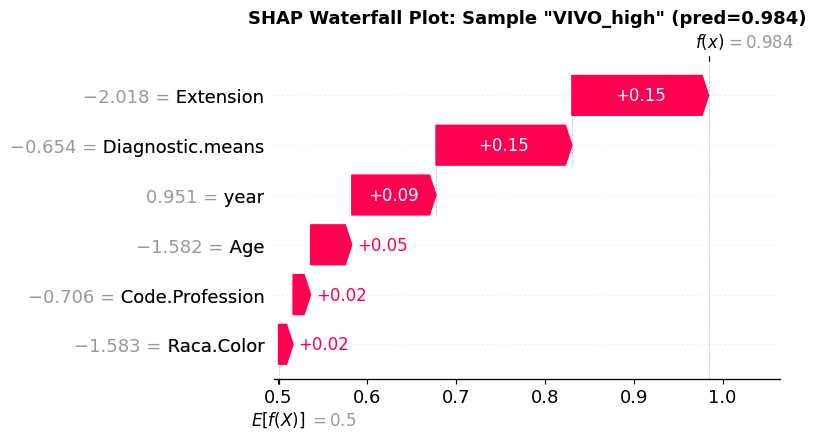

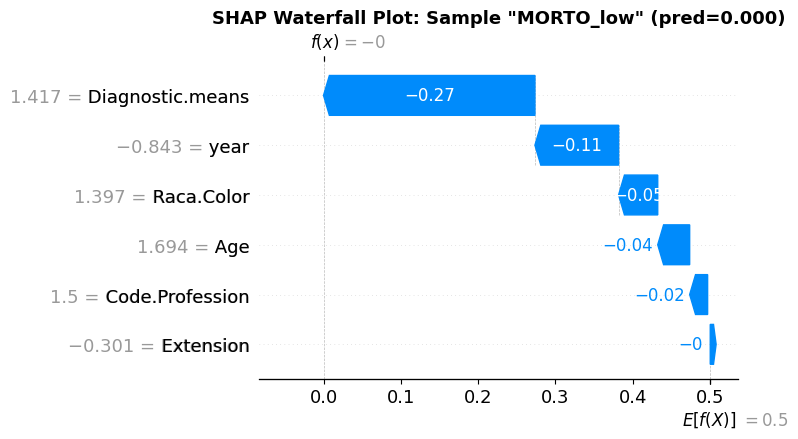

In [15]:
# --- B1: SHAP Waterfall Plot (局部) ---
print("\n[B1] SHAP Waterfall Plot (局部解释)...")

for sample_name, sample_idx, prob in [
    ("VIVO_high", idx_vivo, probs_vivo[idx_vivo]),
    ("MORTO_low", idx_morto, probs_vivo[idx_morto])
]:
    # 处理 base_values: 对于 2 分类 RF, explainer.expected_value 是长度为2的数组
    ev = explainer.expected_value
    if isinstance(ev, (list, np.ndarray)) and len(ev) == 2:
        base_val = ev[1]  # 正类 (VIVO) 的 base value
    elif isinstance(ev, np.ndarray) and ev.ndim > 0:
        base_val = ev[0]
    else:
        base_val = ev

    plt.figure(figsize=(12, 5))
    shap.waterfall_plot(
        shap.Explanation(values=sv[sample_idx],
                          base_values=base_val,
                          data=X_shap[sample_idx],
                          feature_names=feature_names_short),
        show=False, max_display=len(feature_names_short))
    plt.title(f'SHAP Waterfall Plot: Sample "{sample_name}" (pred={prob:.3f})',
              fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(IMG_DIR, f"15g_shap_waterfall_{sample_name}.png"),
                dpi=150, bbox_inches='tight')
    # plt.close()
    print(f"  [图] 15g_shap_waterfall_{sample_name}.png 已保存")

In [16]:
# --- B2: LIME ---
print("\n[B2] LIME 局部解释...")

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    X_tr_final, feature_names=feature_names_short,
    class_names=['MORTO (Death)', 'VIVO (Alive)'],
    mode='classification', random_state=RANDOM_STATE)

for sample_name, sample_idx in [("VIVO_high", idx_vivo), ("MORTO_low", idx_morto)]:
    exp = lime_explainer.explain_instance(
        X_shap[sample_idx], rf_model.predict_proba, num_features=len(feature_names_short),
        labels=[1])  # 只解释正类 (VIVO)

    # 保存 LIME 图
    fig = plt.figure(figsize=(12, 5))
    exp.as_pyplot_figure(label=1)
    plt.title(f'LIME Explanation: Sample "{sample_name}"',
              fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(IMG_DIR, f"15h_lime_{sample_name}.png"),
                dpi=150, bbox_inches='tight')
    # plt.close()
    print(f"  [图] 15h_lime_{sample_name}.png 已保存")

    # 保存 LIME 文本解释
    lime_text = exp.as_list()
    print(f"\n  LIME 特征贡献 ({sample_name}):")
    for feat, contribution in lime_text[:6]:
        direction = "+" if contribution > 0 else "-"
        print(f"    {direction} {feat:<40} {contribution:+.4f}")



[B2] LIME 局部解释...
  [图] 15h_lime_VIVO_high.png 已保存

  LIME 特征贡献 (VIVO_high):
    + Diagnostic.means <= -0.65                +0.5406
    + year > 0.69                              +0.1649
    + Extension <= -0.30                       +0.1458
    + Raca.Color <= -0.59                      +0.1231
    + Age <= -0.57                             +0.0765
    + Code.Profession <= -0.71                 +0.0402
  [图] 15h_lime_MORTO_low.png 已保存

  LIME 特征贡献 (MORTO_low):
    - -0.65 < Diagnostic.means <= 1.42         -0.5170
    - year <= -0.59                            -0.1498
    + Extension <= -0.30                       +0.1264
    - -0.59 < Raca.Color <= 1.40               -0.0870
    - Age > 0.72                               -0.0621
    - Code.Profession > 0.76                   -0.0493


In [17]:
# ============================================================================
# (C) SHAP vs LIME 对比
# ============================================================================
print("\n" + "=" * 70)
print("(C) SHAP vs LIME 对比 — 同一患者, 两种解释")
print("=" * 70)

# 用第三个样本做直接对比
sample_idx_cmp = idx_vivo  # 用 VIVO_high 样本
print(f"\n  对比样本: index={sample_idx_cmp}, 预测概率={probs_vivo[sample_idx_cmp]:.4f}")
print(f"  真实值: {y_shap[sample_idx_cmp]} ({'VIVO' if y_shap[sample_idx_cmp]==1 else 'MORTO'})")

# -- SHAP top 5 --
sv_sample = sv[sample_idx_cmp]
sv_sorted_idx = np.argsort(abs(sv_sample))[::-1][:5]

print(f"\n  SHAP Top 5 特征贡献:")
print(f"  {'Feature':<25} {'SHAP Value':>12} {'Impact':>10}")
print(f"  {'-'*25} {'-'*12} {'-'*10}")
for i in sv_sorted_idx:
    direction = "→ VIVO" if sv_sample[i] > 0 else "→ MORTO"
    print(f"  {feature_names_short[i]:<25} {sv_sample[i]:>+12.4f} {direction}")

# -- LIME top 5 --
exp_cmp = lime_explainer.explain_instance(
    X_shap[sample_idx_cmp], rf_model.predict_proba,
    num_features=len(feature_names_short), labels=[1])
lime_top5 = exp_cmp.as_list(label=1)[:5]

print(f"\n  LIME Top 5 特征贡献:")
print(f"  {'Feature':<40} {'Coefficient':>14} {'Impact':>10}")
print(f"  {'-'*40} {'-'*14} {'-'*10}")
for feat, coeff in lime_top5:
    direction = "→ VIVO" if coeff > 0 else "→ MORTO"
    print(f"  {feat:<40} {coeff:>+14.4f} {direction}")

# --- 图: SHAP vs LIME 排序对比 ---
fig, ax = plt.subplots(figsize=(14, 5))

# SHAP 贡献
shap_contrib = sv_sample[sv_sorted_idx]
x_pos_shap = np.arange(len(sv_sorted_idx))
ax.bar(x_pos_shap, shap_contrib,
       color=['#e74c3c' if v < 0 else '#2ecc71' for v in shap_contrib],
       alpha=0.7, edgecolor='white', width=0.35, label='SHAP')

# LIME 贡献
lime_vals = [coeff for _, coeff in lime_top5]
x_pos_lime = np.arange(len(lime_vals)) + 0.4
ax.bar(x_pos_lime, lime_vals,
       color=['#c0392b' if v < 0 else '#27ae60' for v in lime_vals],
       alpha=0.5, edgecolor='white', width=0.35, label='LIME', hatch='//')

# 合并 x 轴标签: 先 SHAP 名称, 再 LIME 名称
n_total = max(len(sv_sorted_idx), len(lime_top5))
ax.set_xticks(np.concatenate([x_pos_shap, x_pos_lime]))
ax.set_xticklabels(
    [f'SHAP: {feature_names_short[i][:12]}' for i in sv_sorted_idx] +
    [f'LIME: {feat[:12]}' for feat, _ in lime_top5],
    rotation=25, ha='right', fontsize=8)
ax.axhline(y=0, color='gray', linewidth=0.5)
ax.set_ylabel('Feature Contribution', fontsize=11)
ax.set_title('SHAP vs LIME: Same Sample, Different Explanations',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "15i_shap_vs_lime.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("\n  [图] 15i_shap_vs_lime.png 已保存")


(C) SHAP vs LIME 对比 — 同一患者, 两种解释

  对比样本: index=366, 预测概率=0.9842
  真实值: 1.0 (VIVO)

  SHAP Top 5 特征贡献:
  Feature                     SHAP Value     Impact
  ------------------------- ------------ ----------
  Extension                      +0.1539 → VIVO
  Diagnostic.means               +0.1529 → VIVO
  year                           +0.0948 → VIVO
  Age                            +0.0463 → VIVO
  Code.Profession                +0.0198 → VIVO

  LIME Top 5 特征贡献:
  Feature                                     Coefficient     Impact
  ---------------------------------------- -------------- ----------
  Diagnostic.means <= -0.65                       +0.5401 → VIVO
  year > 0.69                                     +0.1700 → VIVO
  Extension <= -0.30                              +0.1421 → VIVO
  Raca.Color <= -0.59                             +0.1058 → VIVO
  Age <= -0.57                                    +0.0750 → VIVO

  [图] 15i_shap_vs_lime.png 已保存


In [18]:
# ============================================================================
# (D) 讨论: 不稳定场景 — 两个相似样本的 LIME 稳定性
# ============================================================================
print("\n" + "=" * 70)
print("(D) LIME 稳定性演示 — 两个相似样本的解释对比")
print("=" * 70)

# 找两个特征值相近的样本 (在 SHAP 子集内)
from sklearn.metrics.pairwise import euclidean_distances
X_shap_subset = X_shap
dist_matrix = euclidean_distances(X_shap_subset)
np.fill_diagonal(dist_matrix, np.inf)
nearest_idx = np.argmin(dist_matrix[idx_vivo])
nearest_dist = dist_matrix[idx_vivo].min()

print(f"\n  样本 A (idx={idx_vivo}):")
print(f"    特征: {[f'{v:.3f}' for v in X_shap_subset[idx_vivo][:3]]}")
print(f"    Pred = {probs_vivo[idx_vivo]:.4f}, True = {y_shap[idx_vivo]}")
print(f"\n  最近邻样本 B (idx={nearest_idx}): 欧氏距离 = {nearest_dist:.4f}")
print(f"    特征: {[f'{v:.3f}' for v in X_shap_subset[nearest_idx][:3]]}")
print(f"    Pred = {probs_vivo[nearest_idx]:.4f}, True = {y_shap[nearest_idx]}")

# 对两个样本分别解释
exp_a = lime_explainer.explain_instance(
    X_shap[idx_vivo], rf_model.predict_proba, num_features=5, labels=[1])
exp_b = lime_explainer.explain_instance(
    X_shap[nearest_idx], rf_model.predict_proba, num_features=5, labels=[1])

print(f"\n  LIME Top 5 对比:")
print(f"  {'Rank':<5} {'Sample A':<35} {'Sample B (nearest)':<35}")
print(f"  {'-'*5} {'-'*35} {'-'*35}")
for i in range(5):
    a_feat = exp_a.as_list(label=1)[i]
    b_feat = exp_b.as_list(label=1)[i]
    print(f"  {i+1:<5} {a_feat[0]:<35} {b_feat[0]:<35}")


(D) LIME 稳定性演示 — 两个相似样本的解释对比

  样本 A (idx=366):
    特征: ['-1.582', '0.951', '-0.706']
    Pred = 0.9842, True = 1.0

  最近邻样本 B (idx=305): 欧氏距离 = 1.0276
    特征: ['-1.521', '0.695', '-0.706']
    Pred = 0.9680, True = 1.0

  LIME Top 5 对比:
  Rank  Sample A                            Sample B (nearest)                 
  ----- ----------------------------------- -----------------------------------
  1     Diagnostic.means <= -0.65           Diagnostic.means <= -0.65          
  2     year > 0.69                         Extension <= -0.30                 
  3     Extension <= -0.30                  0.18 < year <= 0.69                
  4     Raca.Color <= -0.59                 Raca.Color <= -0.59                
  5     Age <= -0.57                        Age <= -0.57                       
